# Notebook 1: Gridworld — Q-Learning mit Epsilon-Greedy

---

## Abgrenzung zum vorherigen Notebook

| | Notebook 0 (Value Iteration) | Dieses Notebook (Q-Learning) |
|-|------------------------------|------------------------------|
| **Lernprinzip** | Berechnung über alle Zustände | Agent lernt durch Ausprobieren |
| **Exploration** | Keine (vollständige Kenntnis der Umgebung) | Epsilon-Greedy-Strategie |
| **Update** | Synchron (alle Zustände auf einmal) | Online (nach jedem Schritt) |
| **Lernrate α** | Nicht nötig (exakte Iteration) | Ja — steuert, wie schnell gelernt wird |
| **Realitätsnähe** | Theoretisches Verfahren | Praxisnäher (kein vollständiges Modell nötig) |

---

## Lernziele

Nach Abschluss dieses Notebooks kannst du:
- das **vollständige Q-Learning-Update** mit Lernrate α verstehen und implementieren
- die **Epsilon-Greedy-Strategie** implementieren und den Trade-off zwischen Exploration und Exploitation erklären
- den Einfluss von **Lernrate α**, **Diskontierungsfaktor γ** und **ε** auf das Training analysieren
- eine gelernte Policy visualisieren und bewerten

---

## Die vollständige Q-Update-Formel (aus den Folien)

$$Q(s, a) \leftarrow Q(s, a) + \alpha \cdot \left[ r + \gamma \cdot \max_{a'} Q(s', a') - Q(s, a) \right]$$

| Symbol | Bedeutung |
|--------|-----------|
| $\alpha$ | **Lernrate** — wie stark neue Information alte überschreibt (0–1) |
| $\gamma$ | **Diskontierungsfaktor** — Gewichtung zukünftiger Belohnungen (0–1) |
| $r$ | **Sofortiger Reward** für Aktion $a$ in Zustand $s$ |
| $s'$ | **Folgezustand** nach der Aktion |
| $[\ldots]$ | **TD-Fehler** (Temporal Difference Error) — Differenz zwischen erwartetem und erhaltenem Reward |

---

## Aufbau der Umgebung

Wir verwenden ein **4×4-Gitter** (komplexer als das 3×3-Beispiel aus Notebook 0):

```
 S  |    |    |
----+----+----+----
    |    |    |
----+----+----+----
    |    |    |
----+----+----+----
    |    |    |  G
```

- **S** = Start (0,0) | **G** = Ziel (3,3)
- **Reward:** -1 pro Schritt (motiviert kürzere Wege!), 0 bei Ziel
- **Warum negativer Reward?** Im Gegensatz zu Notebook 0 lernt der Agent hier, den kürzesten Weg zu nehmen, nicht nur irgendeinen Weg.

## 1. Imports und Umgebungsklasse

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

class GridWorld:
    """
    Einfache Gridworld-Umgebung für Q-Learning.

    Aktionen: 0=oben, 1=rechts, 2=unten, 3=links
    Reward:   -1 pro Schritt, 0 bei Ziel
    """
    def __init__(self, rows=4, cols=4, start=(0, 0), goal=(3, 3)):
        self.rows  = rows
        self.cols  = cols
        self.start = start
        self.goal  = goal
        self.state = start

        # (delta_zeile, delta_spalte) pro Aktion
        self.action_deltas = {
            0: (-1,  0),   # oben
            1: ( 0,  1),   # rechts
            2: ( 1,  0),   # unten
            3: ( 0, -1),   # links
        }
        self.action_names = ['oben', 'rechts', 'unten', 'links']

    def reset(self):
        """Setzt den Agenten auf den Startzustand zurück."""
        self.state = self.start
        return self.state

    def step(self, action):
        """
        Führt eine Aktion aus.
        Returns: (next_state, reward, done)
        """
        dr, dc = self.action_deltas[action]
        r, c   = self.state
        nr, nc = r + dr, c + dc

        # Randbedingungen: an der Wand bleiben
        nr = max(0, min(nr, self.rows - 1))
        nc = max(0, min(nc, self.cols - 1))
        self.state = (nr, nc)

        done   = (self.state == self.goal)
        reward = 0 if done else -1   # -1 pro Schritt → kürzester Weg wird bevorzugt
        return self.state, reward, done

# Kurzer Test
env = GridWorld()
state = env.reset()
print('Startzustand:', state)
next_s, r, done = env.step(1)  # rechts
print(f'Nach Aktion "rechts": Zustand={next_s}, Reward={r}, done={done}')

Startzustand: (0, 0)
Nach Aktion "rechts": Zustand=(0, 1), Reward=-1, done=False


## 2. Epsilon-Greedy-Strategie

Die Epsilon-Greedy-Strategie balanciert Exploration und Exploitation:

- Mit Wahrscheinlichkeit **ε**: zufällige Aktion → **Exploration**
- Mit Wahrscheinlichkeit **1−ε**: beste bekannte Aktion → **Exploitation**

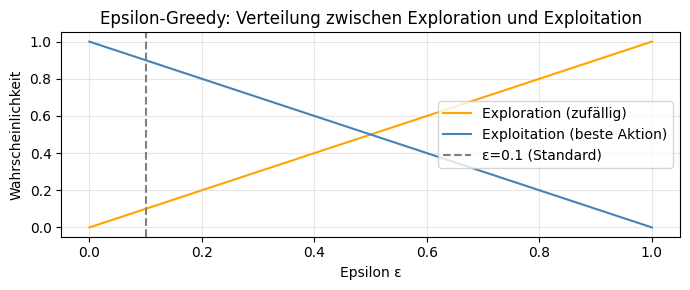

In [ ]:
def epsilon_greedy(state, Q, epsilon, n_actions=4):
    """
    Wählt eine Aktion nach der Epsilon-Greedy-Strategie.

    Args:
        state:    Aktueller Zustand als (zeile, spalte)
        Q:        Q-Tabelle (rows × cols × n_actions)
        epsilon:  Explorationsrate (0=nur Exploitation, 1=nur Exploration)
        n_actions: Anzahl möglicher Aktionen
    Returns:
        Gewählte Aktion (0–3)
    """
    if np.random.rand() < epsilon:
        # Exploration: Zufällige Aktion
        return np.random.choice(n_actions)
    else:
        # Exploitation: Beste bekannte Aktion
        r, c = state
        return np.argmax(Q[r, c])

# Visualisierung der Epsilon-Greedy-Strategie
epsilons = np.linspace(0, 1, 100)
p_explore = epsilons
p_exploit = 1 - epsilons

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(epsilons, p_explore, label='Exploration (zufällig)', color='orange')
ax.plot(epsilons, p_exploit, label='Exploitation (beste Aktion)', color='steelblue')
ax.axvline(x=0.1, color='gray', linestyle='--', label='ε=0.1 (Standard)')
ax.set_xlabel('Epsilon ε')
ax.set_ylabel('Wahrscheinlichkeit')
ax.set_title('Epsilon-Greedy: Verteilung zwischen Exploration und Exploitation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Q-Learning Training

Jetzt implementieren wir das vollständige Q-Learning:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \cdot \underbrace{\left[ r + \gamma \cdot \max_{a'} Q(s', a') - Q(s, a) \right]}_{\text{TD-Fehler}}$$

In [ ]:
def train_q_learning(env, episodes=1000, alpha=0.1, gamma=0.99, epsilon=0.1,
                     epsilon_decay=1.0, epsilon_min=0.01):
    """
    Trainiert einen Q-Learning-Agenten.

    Args:
        env:           GridWorld-Umgebung
        episodes:      Anzahl Trainingsepisoden
        alpha:         Lernrate (0–1)
        gamma:         Diskontierungsfaktor (0–1)
        epsilon:       Start-Explorationsrate
        epsilon_decay: Epsilon-Multiplikator pro Episode (< 1 = Decay)
        epsilon_min:   Minimale Explorationsrate
    Returns:
        Q:             Gelernte Q-Tabelle
        rewards_per_ep: Gesamtreward pro Episode
        steps_per_ep:   Schritte pro Episode
    """
    Q = np.zeros((env.rows, env.cols, 4))
    rewards_per_ep = []
    steps_per_ep   = []
    eps = epsilon

    for ep in range(episodes):
        state    = env.reset()
        done     = False
        total_r  = 0
        steps    = 0

        while not done:
            action = epsilon_greedy(state, Q, eps)
            next_state, reward, done = env.step(action)

            r, c   = state
            nr, nc = next_state

            # ── Q-Update (vollständige Bellman-Formel) ──────────────────
            td_target = reward + gamma * np.max(Q[nr, nc])
            td_error  = td_target - Q[r, c, action]
            Q[r, c, action] += alpha * td_error
            # ────────────────────────────────────────────────────────────

            state    = next_state
            total_r += reward
            steps   += 1

        # Epsilon Decay (optional)
        eps = max(eps * epsilon_decay, epsilon_min)

        rewards_per_ep.append(total_r)
        steps_per_ep.append(steps)

    return Q, rewards_per_ep, steps_per_ep


# ── Training ───────────────────────────────────────────────────────────────
np.random.seed(42)
env = GridWorld()
Q, rewards, steps = train_q_learning(
    env,
    episodes=2000,
    alpha=0.1,
    gamma=0.99,
    epsilon=0.3,
    epsilon_decay=0.995,
    epsilon_min=0.01
)
print(f'Training abgeschlossen.')
print(f'Durchschnittlicher Reward (letzte 100 Episoden): {np.mean(rewards[-100:]):.2f}')
print(f'Durchschnittliche Schritte (letzte 100 Episoden): {np.mean(steps[-100:]):.1f}')
print(f'Optimale Pfadlänge im 4×4-Gitter: 6 Schritte (von (0,0) nach (3,3))')

Training abgeschlossen.
Durchschnittlicher Reward (letzte 100 Episoden): -5.06
Durchschnittliche Schritte (letzte 100 Episoden): 6.1
Optimale Pfadlänge im 4×4-Gitter: 6 Schritte (von (0,0) nach (3,3))


## 4. Lernkurven visualisieren

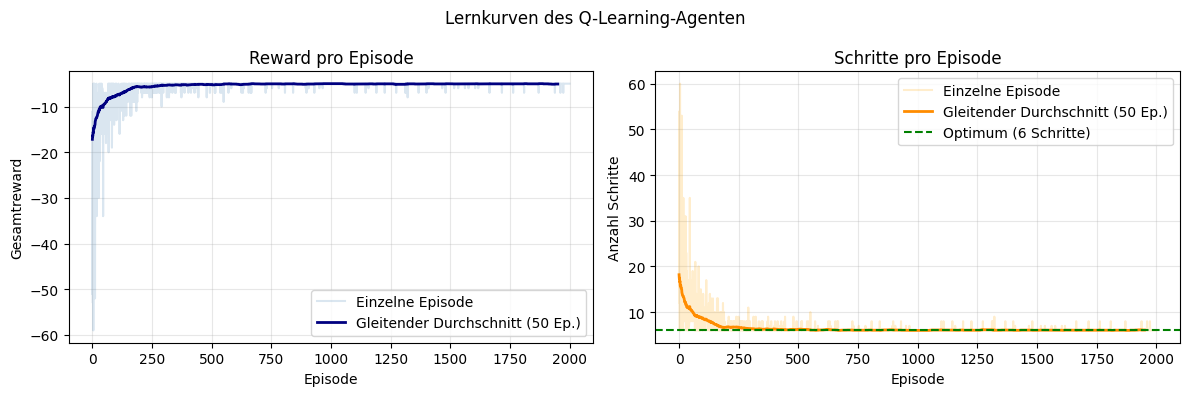

Beobachtung: Der Agent verbessert sich kontinuierlich und nähert sich
dem Optimum von 6 Schritten an.


In [ ]:
def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Rewards pro Episode
ax1.plot(rewards, alpha=0.2, color='steelblue', label='Einzelne Episode')
ax1.plot(range(len(smooth(rewards))), smooth(rewards),
         color='navy', linewidth=2, label='Gleitender Durchschnitt (50 Ep.)')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Gesamtreward')
ax1.set_title('Reward pro Episode')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Schritte pro Episode
ax2.plot(steps, alpha=0.2, color='orange', label='Einzelne Episode')
ax2.plot(range(len(smooth(steps))), smooth(steps),
         color='darkorange', linewidth=2, label='Gleitender Durchschnitt (50 Ep.)')
ax2.axhline(y=6, color='green', linestyle='--', label='Optimum (6 Schritte)')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Anzahl Schritte')
ax2.set_title('Schritte pro Episode')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Lernkurven des Q-Learning-Agenten', fontsize=12)
plt.tight_layout()
plt.show()

print('Beobachtung: Der Agent verbessert sich kontinuierlich und nähert sich')
print('dem Optimum von 6 Schritten an.')

## 5. Policy und Q-Werte visualisieren

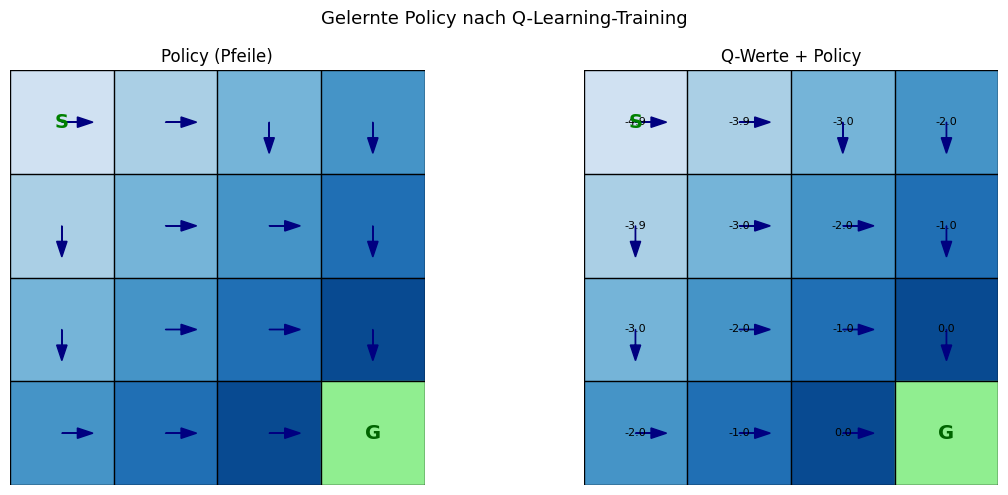

In [ ]:
def visualize_policy_gridworld(env, Q):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    arrow_map = {0: (0, 0.3), 1: (0.3, 0), 2: (0, -0.3), 3: (-0.3, 0)}

    for ax_idx, (ax, show_values) in enumerate(zip(axes, [False, True])):
        ax.set_xlim(0, env.cols)
        ax.set_ylim(0, env.rows)

        # Gitter
        for x in range(env.cols + 1):
            ax.plot([x, x], [0, env.rows], 'k-', lw=1)
        for y in range(env.rows + 1):
            ax.plot([0, env.cols], [y, y], 'k-', lw=1)

        # Hintergrundfarben (max Q-Wert)
        all_q = [np.max(Q[r, c]) for r in range(env.rows) for c in range(env.cols)]
        vmin, vmax = min(all_q), max(all_q)

        for r in range(env.rows):
            for c in range(env.cols):
                py = env.rows - r - 1
                q_val = np.max(Q[r, c])
                norm = (q_val - vmin) / (vmax - vmin + 1e-8)
                color = plt.cm.Blues(0.2 + 0.7 * norm)
                ax.add_patch(plt.Rectangle((c, py), 1, 1, color=color, zorder=0))

                if show_values and (r, c) != env.goal:
                    ax.text(c + 0.5, py + 0.5, f'{q_val:.1f}',
                            ha='center', va='center', fontsize=8, zorder=3)

        # Pfeile
        for r in range(env.rows):
            for c in range(env.cols):
                if (r, c) == env.goal:
                    continue
                a = np.argmax(Q[r, c])
                dx, dy = arrow_map[a]
                py = env.rows - r - 0.5
                ax.arrow(c + 0.5, py, dx, dy,
                         head_width=0.1, length_includes_head=True,
                         color='navy', zorder=2)

        # Start & Ziel
        sr, sc = env.start
        gr, gc = env.goal
        ax.text(sc + 0.5, env.rows - sr - 0.5, 'S',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='green', zorder=4)
        ax.add_patch(plt.Rectangle((gc, env.rows - gr - 1), 1, 1,
                     color='lightgreen', zorder=1))
        ax.text(gc + 0.5, env.rows - gr - 0.5, 'G',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='darkgreen', zorder=4)

        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title('Policy (Pfeile)' if not show_values else 'Q-Werte + Policy')

    plt.suptitle('Gelernte Policy nach Q-Learning-Training', fontsize=13)
    plt.tight_layout()
    plt.show()

visualize_policy_gridworld(env, Q)

## 6. TD-Fehler im Training

Der TD-Fehler misst, wie sehr die aktuelle Q-Schätzung vom tatsächlichen Reward abweicht. Bei gutem Training konvergiert er gegen 0.

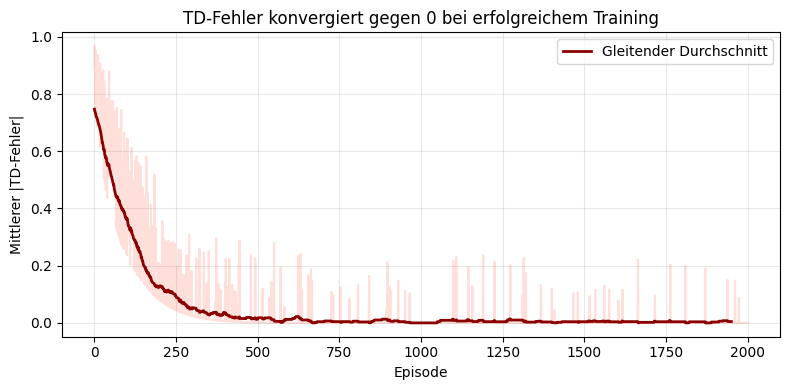

Je kleiner der TD-Fehler, desto besser schätzt die Q-Tabelle die echten Werte.


In [ ]:
def train_q_learning_with_td(env, episodes=2000, alpha=0.1, gamma=0.99,
                              epsilon=0.3, epsilon_decay=0.995, epsilon_min=0.01):
    Q = np.zeros((env.rows, env.cols, 4))
    td_errors_per_ep = []
    eps = epsilon

    for ep in range(episodes):
        state = env.reset()
        done  = False
        td_ep = []

        while not done:
            action = epsilon_greedy(state, Q, eps)
            next_state, reward, done = env.step(action)
            r, c   = state
            nr, nc = next_state
            td_target = reward + gamma * np.max(Q[nr, nc])
            td_error  = td_target - Q[r, c, action]
            Q[r, c, action] += alpha * td_error
            td_ep.append(abs(td_error))
            state = next_state

        eps = max(eps * epsilon_decay, epsilon_min)
        td_errors_per_ep.append(np.mean(td_ep))

    return Q, td_errors_per_ep

np.random.seed(42)
Q2, td_errs = train_q_learning_with_td(env)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(td_errs, alpha=0.2, color='tomato')
ax.plot(range(len(smooth(td_errs))), smooth(td_errs),
        color='darkred', linewidth=2, label='Gleitender Durchschnitt')
ax.set_xlabel('Episode')
ax.set_ylabel('Mittlerer |TD-Fehler|')
ax.set_title('TD-Fehler konvergiert gegen 0 bei erfolgreichem Training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Je kleiner der TD-Fehler, desto besser schätzt die Q-Tabelle die echten Werte.')

---

## 🧩 Aufgaben

### Aufgabe 1: Lernrate α variieren (leicht)

Trainiere den Agenten mit `alpha = 0.01`, `0.1` und `0.9`.
- Was passiert bei sehr kleiner/großer Lernrate?
- Wie verändert sich die Lernkurve?

### Aufgabe 2: Epsilon Decay implementieren (mittel)

Vergleiche zwei Trainingsläufe:
a) Konstantes `ε = 0.1` (kein Decay)
b) `ε` startet bei 1.0 und wird pro Episode mit 0.99 multipliziert

- Welche Strategie konvergiert schneller?
- Wie viele Schritte braucht jede Strategie nach dem Training?

### Aufgabe 3: Hindernisse (schwer)

Füge Hindernisse ins Gitter ein. Der Agent bekommt beim Betreten eines Hindernisses einen Reward von -100 (sehr schlechte Aktion).
- Hindernisse: `[(1,1), (1,2), (2,2)]`
- Findet der Agent trotzdem einen Weg?

---

## ✅ Musterlösungen

---

## Zusammenfassung

| Konzept | Was du gelernt hast |
|---------|--------------------|
| **Q-Learning (online)** | Agent lernt durch Ausprobieren — kein vollständiges Modell der Umgebung nötig |
| **TD-Fehler** | Differenz zwischen erwartetem und erhaltenem Reward — Motor des Lernens |
| **Lernrate α** | Steuert, wie stark neue Erfahrungen alte Schätzungen überschreiben |
| **Epsilon-Greedy** | Balanciert Exploration (neu) und Exploitation (bekannt) |
| **Epsilon Decay** | Exploration nimmt mit der Zeit ab — Agent vertraut mehr auf Gelerntes |
| **Schritt-Penalty** | Negativer Reward pro Schritt motiviert kurze Pfade |